# Smart Multi-Level Parking Optimization
### Project 4 - Combinatorial Optimization & Metaheuristics

**Team:** Houaria Djabir, Yasmine Meriche, Nacer Eddine Missouni

## The problem

Cars arrive at a multi-level car park through the day, and each car must be given a parking
bay as soon as it arrives. We want to serve the demand as well as possible: park as many cars
as we can and, among the parked ones, keep total inconvenience low. Inconvenience here means
walking distance to the exit, an electric car not getting a charger, a long-stay staff member
taking a prime spot that a short-stay visitor needed, a small car wasting a large bay, and
crowding one floor while others stay empty.

We define one shared cost function for a car-to-bay match, implement six methods that each
solve the per-minute matching, and run them on all 10 car parks.

## The Constraints
- Online: at minute t we only know the cars that have already arrived. We never see future arrivals.
- Unknown duration: the policy does not know how long a car will stay. A bay becomes free only when its car actually leaves (the simulation environment knows the real departure time, the decision method does not).
- Irrevocable: once a car is parked it cannot be moved to another bay.
- Simultaneity: cars that arrive in the same minute are decided together (they are all at the gate at the same instant) and matched to the bays free at that moment.
- Size rule (hard): a Large car can only use a Large bay. Compact and Standard cars fit any bay.
- One car per bay at a time: a bay holds one car until that car leaves, then it can be reused.

In [21]:
# Libraries, tunable parameters, data structures, and data loading.
import os, json, csv, math, time, random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, value, PULP_CBC_CMD

random.seed(0)
np.random.seed(0)

DATA_DIR = "data"
VIZ_DIR = "viz"
os.makedirs(VIZ_DIR, exist_ok=True)

# ---- Tunable cost weights (units: metres-equivalent; raw distance ~5-60 m is the base) ----
EV_PEN        = 80.0   # EV placed in a bay without a charger
CHARGER_WASTE = 25.0   # a non-EV taking a charger bay (wastes a scarce resource)
SIZE_WASTE    = 25.0   # a non-large car taking a large bay (wastes a scarce resource)
W_FLOOR       = 15.0   # cost per floor above the ground floor
FLOOR_LOAD    = 20.0   # penalty times the current occupancy fraction of the chosen floor
LAMBDA        = 3.0    # anticipation strength (Hungarian method only)
UNASSIGNED    = 1e6    # cost of leaving a car unparked (dominates any real cost)

# ---- Data structures ----
@dataclass
class Car:
    id: str
    v_type: str        # Compact | Standard | Large
    is_ev: bool
    user_type: str     # Staff | Visitor
    arrival: float     # minute of day (engine only)
    departure: float   # minute of day (engine only; hidden from the policy)

@dataclass
class Bay:
    id: str
    floor: int
    size: str          # Small | Large
    has_charger: bool
    near_exit: bool
    distance_to_exit: float

VEHICLE_RANK = {"Compact": 1, "Standard": 1, "Large": 2}
SPOT_RANK    = {"Small": 1, "Large": 2}

def compatible(car, bay):
    # The single hard rule: a large car needs a large bay.
    return SPOT_RANK[bay.size] >= VEHICLE_RANK[car.v_type]

# ---- Loaders (read directly from the known schema in data/) ----
def load_cars(path):
    out = []
    with open(path, newline="") as f:
        for r in csv.DictReader(f):
            out.append(Car(str(r["Vehicle_ID"]), r["Vehicle_Type"].strip(),
                           r["Electric_Vehicle"].strip() == "1", r["User_Type"].strip(),
                           float(r["Arrival_Time"]), float(r["Departure_Time"])))
    return out

def load_bays(path):
    spots = json.load(open(path))["spots"]
    near = np.percentile([s["distance_to_exit"] for s in spots], 25)  # bottom 25% = near exit
    return [Bay(str(s["spot_id"]), int(s["floor"]), s["size"].capitalize(),
                bool(s["is_ev_spot"]), s["distance_to_exit"] <= near,
                float(s["distance_to_exit"])) for s in spots]

CARS  = load_cars(os.path.join(DATA_DIR, "vehicles.csv"))
PARKS = {i: load_bays(os.path.join(DATA_DIR, f"parking{i}.json")) for i in range(1, 11)}
print(f"Loaded {len(CARS)} cars and {len(PARKS)} car parks. pulp/CBC ready.")

Loaded 1000 cars and 10 car parks. pulp/CBC ready.


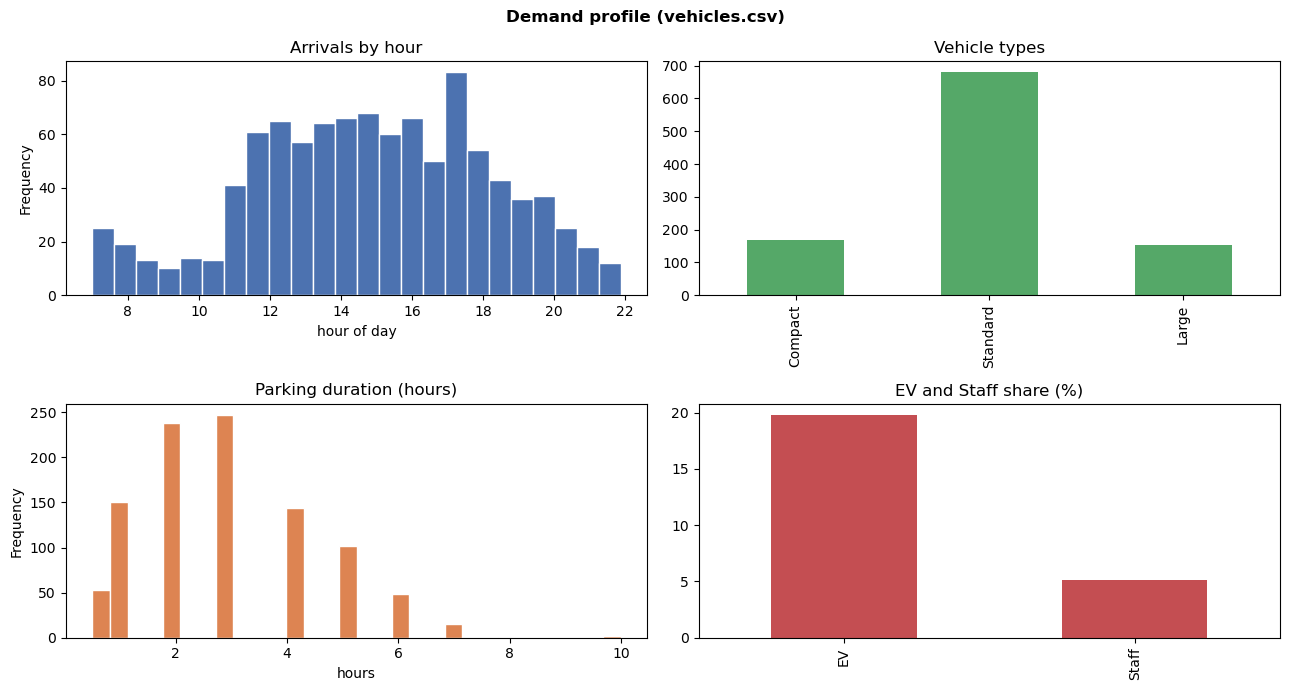

Peak concurrent demand: 355 cars present at once

 Park  Bays  Large_bays  Chargers  Floors  Peak_demand Saturates
    1   417         134        77       1          355        no
    2   377         184        32       1          355        no
    3   271          96        19       3          355       yes
    4   485         156        61       4          355        no
    5   428         123        52       4          355        no
    6   444         140        58       4          355        no
    7   432         146        50       2          355        no
    8    98          25        15       1          355       yes
    9   486         157        64       3          355        no
   10   100          42        20       3          355       yes


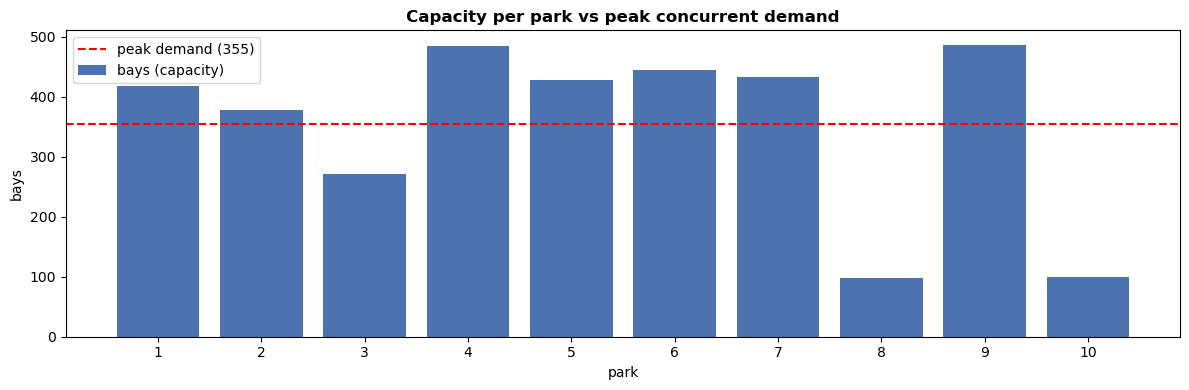

In [22]:
# Exploratory data analysis: the demand, and the 10 car parks.

# 1) Demand profile of the cars.
dfc = pd.DataFrame([{"hour": c.arrival / 60, "type": c.v_type, "ev": c.is_ev,
                     "user": c.user_type, "dur_h": (c.departure - c.arrival) / 60} for c in CARS])
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Demand profile (vehicles.csv)", fontweight="bold")
dfc["hour"].plot.hist(bins=24, ax=ax[0, 0], color="#4C72B0", edgecolor="white")
ax[0, 0].set_title("Arrivals by hour"); ax[0, 0].set_xlabel("hour of day")
dfc["type"].value_counts().reindex(["Compact", "Standard", "Large"]).plot.bar(
    ax=ax[0, 1], color="#55A868"); ax[0, 1].set_title("Vehicle types"); ax[0, 1].set_xlabel("")
dfc["dur_h"].plot.hist(bins=30, ax=ax[1, 0], color="#DD8452", edgecolor="white")
ax[1, 0].set_title("Parking duration (hours)"); ax[1, 0].set_xlabel("hours")
pd.Series({"EV": dfc["ev"].mean() * 100, "Staff": (dfc["user"] == "Staff").mean() * 100}).plot.bar(
    ax=ax[1, 1], color="#C44E52"); ax[1, 1].set_title("EV and Staff share (%)"); ax[1, 1].set_xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "mt_demand.png"), dpi=120, bbox_inches="tight"); plt.show()

# 2) Peak concurrent demand (ground truth from arrival/departure) vs each park's capacity.
events = sorted([(c.arrival, 1) for c in CARS] + [(c.departure, -1) for c in CARS])
cur = peak = 0
for _, e in events:
    cur += e; peak = max(peak, cur)

rows = []
for i, bays in PARKS.items():
    rows.append({"Park": i, "Bays": len(bays),
                 "Large_bays": sum(b.size == "Large" for b in bays),
                 "Chargers": sum(b.has_charger for b in bays),
                 "Floors": max(b.floor for b in bays),
                 "Peak_demand": peak,
                 "Saturates": "yes" if len(bays) < peak else "no"})
park_table = pd.DataFrame(rows)
print(f"Peak concurrent demand: {peak} cars present at once\n")
print(park_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(park_table["Park"], park_table["Bays"], color="#4C72B0", label="bays (capacity)")
ax.axhline(peak, color="red", ls="--", lw=1.5, label=f"peak demand ({peak})")
ax.set_xticks(park_table["Park"]); ax.set_xlabel("park"); ax.set_ylabel("bays")
ax.set_title("Capacity per park vs peak concurrent demand", fontweight="bold"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "mt_capacity.png"), dpi=120, bbox_inches="tight"); plt.show()

## The Cost function

Every method minimizes the same cost when matching a car to a bay (lower is better). The cost
is scarcity aware: it does not only look at the car in front of us, it also protects the bays
that are scarce and valuable.

- Walking distance to the exit, the base inconvenience.
- Staff are pushed far: staff stay long, so for a staff car the cost uses (Dmax - distance). This frees the prime near-exit bays for the many short-stay visitors. Visitors keep the normal distance, so they prefer near bays.
- Floor penalty: upper floors add cost, since reaching them takes longer.
- EV needs a charger: a penalty if an electric car is placed in a bay without a charger.
- Charger preservation: a penalty if a non-electric car takes a charger bay, so chargers stay free for EVs.
- Large-bay preservation: a penalty if a small car takes a large bay, so large bays stay free for large cars.
- Floor load balancing: a mild penalty proportional to how full the chosen floor already is, which spreads cars across levels.

All weights are tunable constants at the top of the notebook. The two preservation terms
(charger and large-bay) are the ones the anticipation module scales for the Hungarian method.

In [23]:
# The shared scarcity-aware cost of putting `car` in `bay` (lower is better).
#   dmax      : farthest distance in this park (used by the staff flip)
#   floor_occ : dict {floor: occupancy fraction now} (used by the load-balancing term)
#   cw, sw    : effective charger / large-bay preservation weights. The anticipation module
#               passes scaled values for the Hungarian method; every other method uses the
#               static defaults CHARGER_WASTE / SIZE_WASTE.
def cost(car, bay, dmax, floor_occ, cw=CHARGER_WASTE, sw=SIZE_WASTE):
    d = bay.distance_to_exit
    access = (dmax - d) if car.user_type == "Staff" else d   # staff stay long -> pushed far
    c = access + W_FLOOR * (bay.floor - 1)
    if car.is_ev and not bay.has_charger:
        c += EV_PEN
    if bay.has_charger and not car.is_ev:
        c += cw
    if bay.size == "Large" and VEHICLE_RANK[car.v_type] < SPOT_RANK["Large"]:
        c += sw
    c += FLOOR_LOAD * floor_occ.get(bay.floor, 0.0)           # discourage crowding a floor
    return c

## The Algorithms

Every minute we must match the cars that just arrived to the bays free right now, at minimum
total cost. That is a min-cost assignment problem, and the six methods are six ways to solve it.

### Baseline (greedy):
Each car, one at a time, takes the nearest free compatible bay (distance only). No joint matching and no scarcity terms. This is the obvious approach we compare against.

### ILP: 
Integer Linear Programming. We write the matching as binary variables x[car, bay] with a linear objective and the constraints "each car at most one bay" and "each bay at most one car", and solve it exactly with CBC (via pulp). It is the formal, declarative statement of the problem.
    
### B&B: 
Branch and Bound. A depth-first search over the cars that assigns each car to a bay or leaves it unparked, pruning any branch whose cost already passes the best solution found (with an admissible look-ahead bound). It reaches the same optimum as ILP, by search rather than by a solver.

### SA: 
Simulated Annealing. A metaheuristic local search that starts from a greedy matching and improves it with small moves (reassign a car, or swap two cars' bays), sometimes accepting worse moves to escape local minima. Its effort scales with the number of cars in the minute.

### GA: 
Genetic Algorithm. A metaheuristic that evolves a population of matchings with tournament selection, one-point crossover and swap mutation, repairing each child so no two cars share a bay. Its effort also scales with the minute size.

### Hungarian: 
the Kuhn-Munkres algorithm, the specialized O(n^3) algorithm that solves the assignment problem exactly and fast. It is also the only method carrying the always-on anticipation: it scales the charger and large-bay preservation penalties using the arrivals seen so far and the current scarcity, to reserve those bays for likely future high-need cars.

### Note: 
ILP, B&B and Hungarian are three exact methods, so they return the same optimal matching on the same cost; SA and GA approximate it. Because Hungarian also uses anticipation, it minimizes a slightly different (history-adjusted) objective, To compare fairly we therefore score every method's final placement on one common objective, the static cost with no anticipation, and we report that total cost alongside the real-world KPIs.

In [24]:
# Implementation of the six methods. Each one solves a single minute and returns
# {car_id: bay_id or None}. They share the candidate-pool helper and the cost function above.

def _cheapest(car, free, dmax, fo, cw, sw):
    # Cheapest compatible free bay for one car (used for single-car minutes and warm starts).
    best, bc = None, math.inf
    for b in free:
        if compatible(car, b):
            k = cost(car, b, dmax, fo, cw, sw)
            if k < bc:
                bc, best = k, b
    return best.id if best else None

def _pool(group, free, dmax, fo, cw, sw):
    # Candidate bays = union of each car's (g+5) cheapest compatible free bays. The optimal
    # matching of g cars never needs more, so this keeps every solver's search tiny.
    g = len(group); ids = set()
    for c in group:
        comp = sorted((b for b in free if compatible(c, b)), key=lambda b: cost(c, b, dmax, fo, cw, sw))
        ids.update(b.id for b in comp[:g + 5])
    return [b for b in free if b.id in ids]

# ---- Baseline: nearest free compatible bay, one car at a time, distance only ----
def baseline_assign(group, free, dmax, fo, cw, sw):
    used, out = set(), {}
    for c in group:
        best, bd = None, math.inf
        for b in free:
            if b.id not in used and compatible(c, b) and b.distance_to_exit < bd:
                best, bd = b, b.distance_to_exit
        out[c.id] = best.id if best else None
        if best:
            used.add(best.id)
    return out

# ---- Hungarian (Kuhn-Munkres) exact assignment, O(n^3) ----
def _hungarian(C):
    # Minimum-cost assignment for an n x m cost matrix with n <= m. Returns assign[row] = col.
    n, m = len(C), len(C[0])
    INF = float("inf")
    u = [0.0] * (n + 1); v = [0.0] * (m + 1); p = [0] * (m + 1); way = [0] * (m + 1)
    for i in range(1, n + 1):
        p[0] = i; j0 = 0
        minv = [INF] * (m + 1); used = [False] * (m + 1)
        while True:
            used[j0] = True; i0, delta, j1 = p[j0], INF, -1
            for j in range(1, m + 1):
                if not used[j]:
                    cur = C[i0 - 1][j - 1] - u[i0] - v[j]
                    if cur < minv[j]:
                        minv[j], way[j] = cur, j0
                    if minv[j] < delta:
                        delta, j1 = minv[j], j
            for j in range(m + 1):
                if used[j]:
                    u[p[j]] += delta; v[j] -= delta
                else:
                    minv[j] -= delta
            j0 = j1
            if p[j0] == 0:
                break
        while j0:
            j1 = way[j0]; p[j0] = p[j1]; j0 = j1
    assign = [-1] * n
    for j in range(1, m + 1):
        if p[j] > 0:
            assign[p[j] - 1] = j - 1
    return assign

def _matrix(group, pool, dmax, fo, cw, sw):
    # Build the cost matrix: rows = cars, cols = [candidate bays] + [g "street" columns].
    # A street column (cost UNASSIGNED) lets a car stay unparked; incompatible cells are
    # set above UNASSIGNED so they are never chosen.
    g, m = len(group), len(pool); INC = UNASSIGNED * 10
    M = [[0.0] * (m + g) for _ in range(g)]
    for i, c in enumerate(group):
        for j, b in enumerate(pool):
            M[i][j] = cost(c, b, dmax, fo, cw, sw) if compatible(c, b) else INC
        for j in range(m, m + g):
            M[i][j] = UNASSIGNED
    return M

def hungarian_assign(group, free, dmax, fo, cw, sw):
    if len(group) == 1:
        return {group[0].id: _cheapest(group[0], free, dmax, fo, cw, sw)}
    pool = _pool(group, free, dmax, fo, cw, sw)
    if not pool:
        return {c.id: None for c in group}
    M = _matrix(group, pool, dmax, fo, cw, sw); m = len(pool)
    sol = _hungarian(M); out = {}
    for i, c in enumerate(group):
        j = sol[i]
        out[c.id] = pool[j].id if (j < m and M[i][j] < UNASSIGNED) else None
    return out

# ---- ILP: same matching as a binary program, solved exactly by CBC ----
def ilp_assign(group, free, dmax, fo, cw, sw):
    if len(group) == 1:
        return {group[0].id: _cheapest(group[0], free, dmax, fo, cw, sw)}
    pool = _pool(group, free, dmax, fo, cw, sw)
    if not pool:
        return {c.id: None for c in group}
    prob = LpProblem("minute", LpMinimize)
    x = {(c.id, b.id): LpVariable(f"x_{c.id}_{b.id}", cat="Binary")
         for c in group for b in pool if compatible(c, b)}
    # objective: matched cost + UNASSIGNED for every car left unmatched
    prob += (lpSum(cost(c, b, dmax, fo, cw, sw) * x[c.id, b.id]
                   for c in group for b in pool if (c.id, b.id) in x)
             + lpSum(UNASSIGNED * (1 - lpSum(x[c.id, b.id] for b in pool if (c.id, b.id) in x))
                     for c in group))
    for c in group:                                   # each car at most one bay
        prob += lpSum(x[c.id, b.id] for b in pool if (c.id, b.id) in x) <= 1
    for b in pool:                                    # each bay at most one car
        prob += lpSum(x[c.id, b.id] for c in group if (c.id, b.id) in x) <= 1
    prob.solve(PULP_CBC_CMD(msg=0))
    out = {c.id: None for c in group}
    for (cid, bid), var in x.items():
        if value(var) and value(var) > 0.5:
            out[cid] = bid
    return out

# ---- B&B: depth-first search with an admissible look-ahead bound ----
def bb_assign(group, free, dmax, fo, cw, sw, time_limit=2.0):
    if len(group) == 1:
        return {group[0].id: _cheapest(group[0], free, dmax, fo, cw, sw)}
    pool = _pool(group, free, dmax, fo, cw, sw)
    if not pool:
        return {c.id: None for c in group}
    by = {b.id: b for b in pool}
    cand = {c.id: sorted([b for b in pool if compatible(c, b)],
                         key=lambda b: cost(c, b, dmax, fo, cw, sw)) for c in group}
    cheap = [cost(c, cand[c.id][0], dmax, fo, cw, sw) if cand[c.id] else UNASSIGNED for c in group]
    suf = [0.0] * (len(group) + 1)                    # suffix lower bound (ignores conflicts)
    for i in range(len(group) - 1, -1, -1):
        suf[i] = suf[i + 1] + cheap[i]
    def acost(a):
        return sum(cost(group[i], by[a[group[i].id]], dmax, fo, cw, sw) if a[group[i].id] else UNASSIGNED
                   for i in range(len(group)))
    warm, used = {}, set()                            # greedy warm start
    for c in group:
        pick = next((b for b in cand[c.id] if b.id not in used), None)
        warm[c.id] = pick.id if pick else None
        if pick:
            used.add(pick.id)
    best = [acost(warm)]; bestsol = [dict(warm)]; t0 = time.time(); to = [False]
    def rec(i, a, used, acc):
        if time.time() - t0 > time_limit:
            to[0] = True; return
        if acc + suf[i] >= best[0]:
            return
        if i == len(group):
            best[0] = acc; bestsol[0] = dict(a); return
        c = group[i]
        for b in cand[c.id]:
            if b.id in used:
                continue
            k = cost(c, b, dmax, fo, cw, sw)
            if acc + k >= best[0]:
                break
            a[c.id] = b.id; used.add(b.id)
            rec(i + 1, a, used, acc + k)
            used.discard(b.id); a[c.id] = None
            if to[0]:
                return
        if acc + UNASSIGNED < best[0]:
            a[c.id] = None; rec(i + 1, a, used, acc + UNASSIGNED)
    rec(0, {c.id: None for c in group}, set(), 0.0)
    return bestsol[0]

# ---- SA: simulated annealing, effort scales with the minute size ----
def sa_assign(group, free, dmax, fo, cw, sw):
    if len(group) == 1:
        return {group[0].id: _cheapest(group[0], free, dmax, fo, cw, sw)}
    pool = _pool(group, free, dmax, fo, cw, sw)
    if not pool:
        return {c.id: None for c in group}
    by = {b.id: b for b in pool}; ids = [c.id for c in group]; cm = {c.id: c for c in group}
    cand = {c.id: [b for b in pool if compatible(c, b)] for c in group}
    def acost(a):
        return sum(cost(cm[cid], by[a[cid]], dmax, fo, cw, sw) if a[cid] else UNASSIGNED for cid in ids)
    used, cur = set(), {}                             # greedy start
    for cid in ids:
        opts = sorted(cand[cid], key=lambda b: cost(cm[cid], b, dmax, fo, cw, sw))
        pick = next((b for b in opts if b.id not in used), None)
        cur[cid] = pick.id if pick else None
        if pick:
            used.add(pick.id)
    cur_c = acost(cur); best, best_c = dict(cur), cur_c
    g = len(group); iters = min(1500, 40 * g); T = 40.0
    for _ in range(iters):
        a = dict(cur); occ = {b for b in a.values() if b}
        if random.random() < 0.5 and g >= 2:          # swap two cars' bays
            i, j = random.sample(ids, 2); a[i], a[j] = a[j], a[i]
            if any(a[k] is not None and not compatible(cm[k], by[a[k]]) for k in (i, j)):
                a = dict(cur)
        else:                                         # reassign one car
            cid = random.choice(ids)
            opts = [b for b in cand[cid] if b.id not in occ or b.id == a[cid]]
            if opts:
                a[cid] = random.choice(opts).id
        ac = acost(a); d = ac - cur_c
        if d < 0 or random.random() < math.exp(-d / max(T, 1e-9)):
            cur, cur_c = a, ac
            if cur_c < best_c:
                best, best_c = dict(cur), cur_c
        T = max(0.5, T * 0.95)
    return best

# ---- GA: genetic algorithm, effort scales with the minute size ----
def ga_assign(group, free, dmax, fo, cw, sw):
    if len(group) == 1:
        return {group[0].id: _cheapest(group[0], free, dmax, fo, cw, sw)}
    pool = _pool(group, free, dmax, fo, cw, sw)
    if not pool:
        return {c.id: None for c in group}
    by = {b.id: b for b in pool}; ids = [c.id for c in group]; cm = {c.id: c for c in group}
    cand = {c.id: sorted([b for b in pool if compatible(c, b)],
                         key=lambda b: cost(cm[c.id], b, dmax, fo, cw, sw)) for c in group}
    def repair(genes):                                # make a chromosome a valid matching
        used, out = set(), []
        for cid, bid in zip(ids, genes):
            ok = bid is not None and bid not in used and any(b.id == bid for b in cand[cid])
            if not ok:
                bid = next((b.id for b in cand[cid] if b.id not in used), None)
            if bid is not None:
                used.add(bid)
            out.append(bid)
        return out
    def fit(genes):
        return sum(cost(cm[cid], by[bid], dmax, fo, cw, sw) if bid else UNASSIGNED
                   for cid, bid in zip(ids, genes))
    g = len(group); pop_size = min(60, 4 * g); gens = min(80, 8 * g)
    pop = [repair([cand[cid][0].id if cand[cid] else None for cid in ids])]
    while len(pop) < pop_size:
        pop.append(repair([random.choice(cand[cid]).id if cand[cid] else None for cid in ids]))
    best, best_c = None, math.inf
    for _ in range(gens):
        costs = [fit(x) for x in pop]
        order = sorted(range(len(pop)), key=lambda i: costs[i])
        if costs[order[0]] < best_c:
            best_c, best = costs[order[0]], pop[order[0]][:]
        new = [pop[order[0]][:], pop[order[min(1, len(order) - 1)]][:]]   # elitism
        while len(new) < pop_size:
            a = min(random.sample(range(len(pop)), min(3, len(pop))), key=lambda i: costs[i])
            b = min(random.sample(range(len(pop)), min(3, len(pop))), key=lambda i: costs[i])
            cut = random.randint(1, g - 1)
            child = pop[a][:cut] + pop[b][cut:]
            if random.random() < 0.2:                 # swap mutation
                i, j = random.sample(range(g), 2); child[i], child[j] = child[j], child[i]
            new.append(repair(child))
        pop = new
    return dict(zip(ids, best))

METHODS = {"Baseline": baseline_assign, "ILP": ilp_assign, "B&B": bb_assign,
           "SA": sa_assign, "GA": ga_assign, "Hungarian": hungarian_assign}
ANTICIPATE_METHODS = {"Hungarian"}                    # anticipation is on for Hungarian only
print("Six methods ready:", ", ".join(METHODS))

Six methods ready: Baseline, ILP, B&B, SA, GA, Hungarian


## Simulation

The simulation plays each car park forward minute by minute, strictly online:
1. Release the bays whose car has already left. This is the only use of the hidden real departure time, and it belongs to the environment, not to the method.
2. Take the cars arriving this minute and the bays free now, and compute the current floor occupancy.
3. For the Hungarian method only, update the anticipation signal from the arrivals seen so far and the current scarcity, and scale the two preservation weights. Every other method uses the static weights.
4. Match the cars to bays with the chosen method, commit the choice (irrevocable), and log it.

We run all six methods on all 10 car parks and record, per park and method, the KPIs and the runtime.

In [25]:
# The online engine: play one park forward for one method, return a per-car log.
def simulate(cars, bays, method_name):
    assign_fn = METHODS[method_name]
    dmax = max(b.distance_to_exit for b in bays)
    by_id = {b.id: b for b in bays}
    floor_cap = {}
    for b in bays:
        floor_cap[b.floor] = floor_cap.get(b.floor, 0) + 1
    n_charger = sum(b.has_charger for b in bays) or 1
    n_large = sum(b.size == "Large" for b in bays) or 1

    occupied = {}                                     # bay_id -> hidden true departure time
    hist = {"seen": 0, "ev": 0, "large": 0}
    groups = {}
    for c in cars:
        groups.setdefault(int(c.arrival), []).append(c)

    log = []
    for t in sorted(groups):
        for bid in [b for b, dep in occupied.items() if dep <= t]:
            del occupied[bid]                         # cars that have departed free their bays
        free = [b for b in bays if b.id not in occupied]
        group = sorted(groups[t], key=lambda c: c.id)

        focc = {fl: sum(1 for bid in occupied if by_id[bid].floor == fl) / cap
                for fl, cap in floor_cap.items()}     # floor occupancy fractions now

        hist["seen"] += len(group)                    # these arrivals are now "seen"
        hist["ev"] += sum(c.is_ev for c in group)
        hist["large"] += sum(c.v_type == "Large" for c in group)

        if method_name in ANTICIPATE_METHODS and hist["seen"] > 0:
            p_ev = hist["ev"] / hist["seen"]; p_lg = hist["large"] / hist["seen"]
            ch_occ = sum(1 for bid in occupied if by_id[bid].has_charger) / n_charger
            lg_occ = sum(1 for bid in occupied if by_id[bid].size == "Large") / n_large
            cw = CHARGER_WASTE * (1 + LAMBDA * p_ev * ch_occ)
            sw = SIZE_WASTE * (1 + LAMBDA * p_lg * lg_occ)
        else:
            cw, sw = CHARGER_WASTE, SIZE_WASTE

        assign = assign_fn(group, free, dmax, focc, cw, sw)
        for c in group:
            bid = assign.get(c.id)
            if bid is not None:
                occupied[bid] = c.departure           # engine books the true departure
            b = by_id[bid] if bid else None
            log.append({"car_id": c.id, "minute": t, "v_type": c.v_type, "is_ev": c.is_ev,
                        "user_type": c.user_type, "parked": bid is not None,
                        "distance": b.distance_to_exit if b else None,
                        "floor": b.floor if b else None,
                        "has_charger": b.has_charger if b else None,
                        "is_large_bay": (b.size == "Large") if b else None,
                        # ref_cost: the chosen bay scored on the STATIC objective (same
                        # weights for every method) so total cost is comparable across methods
                        "ref_cost": cost(c, b, dmax, focc, CHARGER_WASTE, SIZE_WASTE) if b else None})
    return pd.DataFrame(log)

# KPIs for one run.
N_EV = sum(c.is_ev for c in CARS)
def kpis(df):
    p = df[df.parked]
    vis = p[p.user_type == "Visitor"]; stf = p[p.user_type == "Staff"]
    ev = p[p.is_ev]; nonev = p[~p.is_ev]; nonlarge = p[p.v_type != "Large"]
    share = p.groupby("floor").size() / max(len(p), 1) * 100
    return {
        "Parked_%": round(100 * len(p) / len(df), 1),
        "Total_cost": round(float(p.ref_cost.sum()), 0),       # objective on static weights
        "Avg_cost": round(float(p.ref_cost.mean()), 2) if len(p) else 0.0,
        "EV_charged_%": round(100 * int(ev.has_charger.sum()) / N_EV, 1),
        "Charger_waste_%": round(100 * int(nonev.has_charger.sum()) / max(len(nonev), 1), 1),
        "LargeBay_waste_%": round(100 * int(nonlarge.is_large_bay.sum()) / max(len(nonlarge), 1), 1),
        "Visitor_dist": round(vis.distance.mean(), 1) if len(vis) else 0.0,
        "Staff_dist": round(stf.distance.mean(), 1) if len(stf) else 0.0,
        "Floor_spread": round(float(share.std()), 1) if len(share) > 1 else 0.0,
    }

# Run every method on every park.
rows, LOGS_PARK1 = [], {}
for i, bays in PARKS.items():
    for name in METHODS:
        t0 = time.time(); df = simulate(CARS, bays, name); rt = time.time() - t0
        if i == 1:
            LOGS_PARK1[name] = df
        k = kpis(df); k.update({"Park": i, "Method": name, "Runtime_s": round(rt, 2)})
        rows.append(k)
    print(f"park {i:2d} done")

results = pd.DataFrame(rows)
results.to_csv(os.path.join(VIZ_DIR, "mt_results.csv"), index=False)
print("\nMean over the 10 parks:")
print(results.groupby("Method")[["Parked_%", "Total_cost", "EV_charged_%", "Charger_waste_%",
      "LargeBay_waste_%", "Visitor_dist", "Staff_dist", "Runtime_s"]].mean().round(2)
      .reindex(list(METHODS)).to_string())

park  1 done
park  2 done
park  3 done
park  4 done
park  5 done
park  6 done
park  7 done
park  8 done
park  9 done
park 10 done

Mean over the 10 parks:
           Parked_%  Total_cost  EV_charged_%  Charger_waste_%  LargeBay_waste_%  Visitor_dist  Staff_dist  Runtime_s
Method                                                                                                               
Baseline      88.20     71500.2         24.24            24.59             24.53         31.89       31.21       0.08
ILP           88.22     55661.7         55.31             8.80             12.94         31.73       84.37       6.44
B&B           88.21     56043.8         54.64             9.11             13.30         31.83       84.41       1.58
SA            88.24     56075.9         54.69             9.11             13.27         31.85       84.36       0.31
GA            88.26     56393.0         54.50             9.54             13.71         31.81       84.30       0.96
Hungarian     88.22

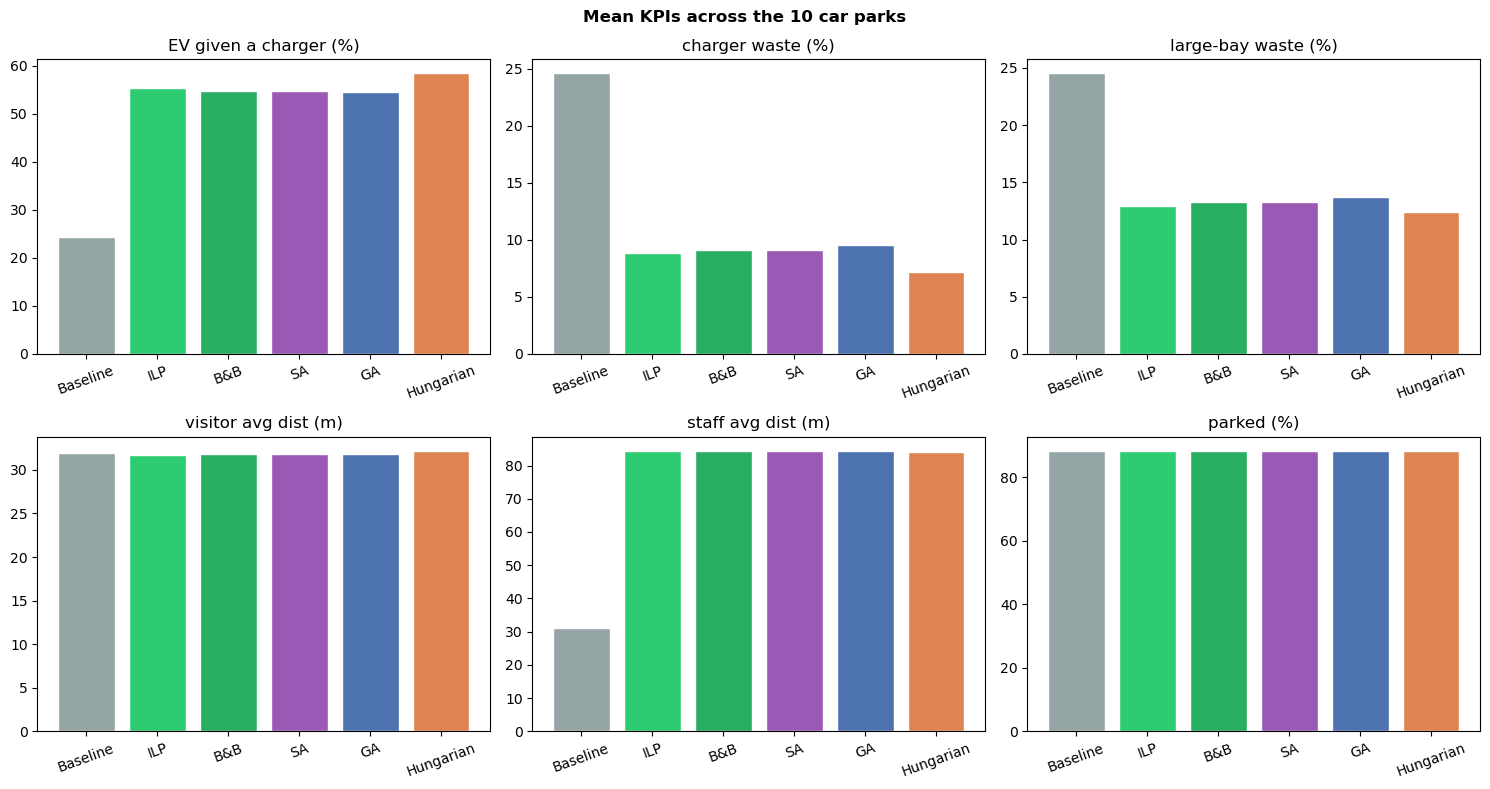

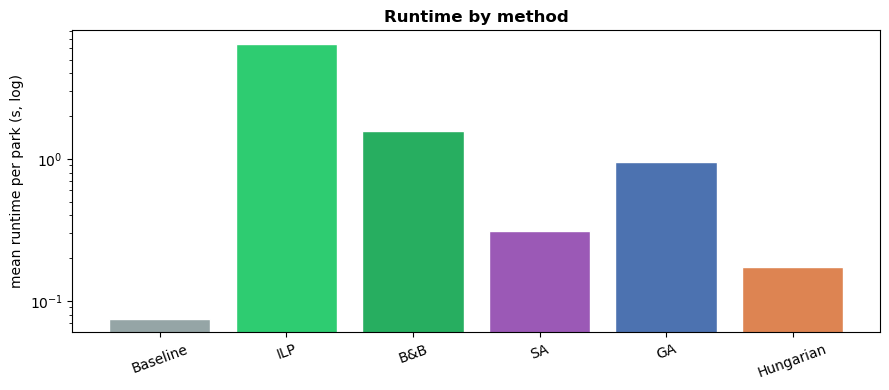

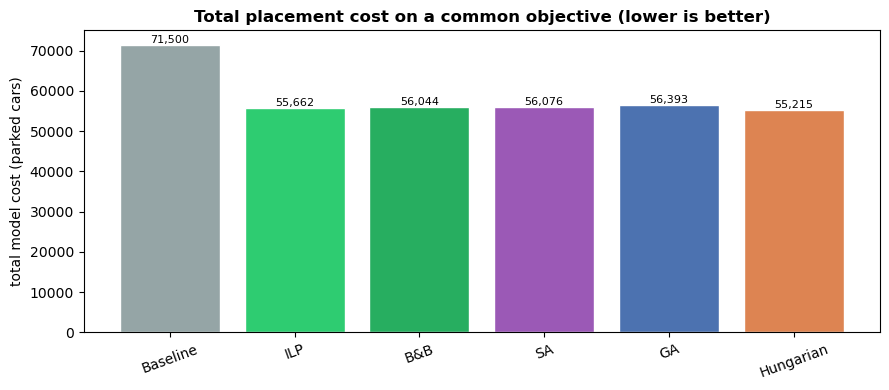

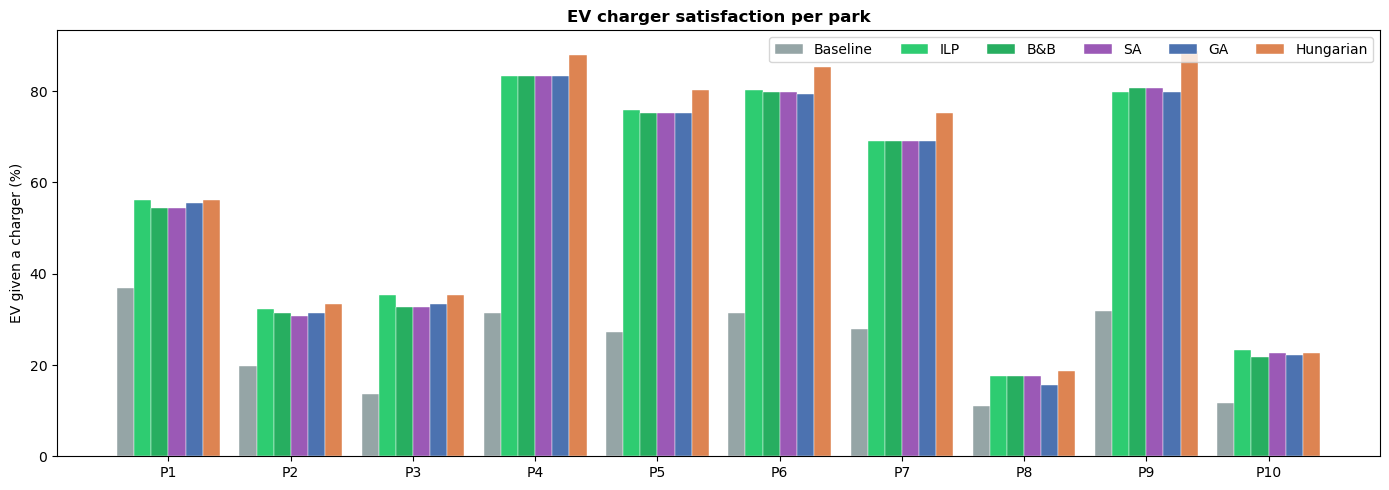

           Parked_%  Total_cost  Avg_cost  EV_charged_%  Charger_waste_%  LargeBay_waste_%  Visitor_dist  Staff_dist  Floor_spread  Runtime_s
Method                                                                                                                                       
Baseline      88.20     71500.2    78.999         24.24            24.59             24.53         31.89       31.21          4.44      0.075
ILP           88.22     55661.7    62.078         55.31             8.80             12.94         31.73       84.37         10.34      6.439
B&B           88.21     56043.8    62.518         54.64             9.11             13.30         31.83       84.41         10.27      1.576
SA            88.24     56075.9    62.514         54.69             9.11             13.27         31.85       84.36         10.21      0.310
GA            88.26     56393.0    63.134         54.50             9.54             13.71         31.81       84.30         10.32      0.958
Hungar

In [26]:
# Comparative analysis and visualisations.
ORDER = ["Baseline", "ILP", "B&B", "SA", "GA", "Hungarian"]
COL = {"Baseline": "#95a5a6", "ILP": "#2ecc71", "B&B": "#27ae60",
       "SA": "#9b59b6", "GA": "#4C72B0", "Hungarian": "#DD8452"}
agg = results.groupby("Method").mean(numeric_only=True).reindex(ORDER)

# 1) Mean KPI panel across the 10 parks.
panel = [("EV_charged_%", "EV given a charger (%)"), ("Charger_waste_%", "charger waste (%)"),
         ("LargeBay_waste_%", "large-bay waste (%)"), ("Visitor_dist", "visitor avg dist (m)"),
         ("Staff_dist", "staff avg dist (m)"), ("Parked_%", "parked (%)")]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Mean KPIs across the 10 car parks", fontweight="bold")
for ax, (col, lab) in zip(axes.ravel(), panel):
    ax.bar(ORDER, [agg.loc[m, col] for m in ORDER], color=[COL[m] for m in ORDER], edgecolor="white")
    ax.set_title(lab); ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "mt_kpis.png"), dpi=120, bbox_inches="tight"); plt.show()

# 2) Runtime by method (log scale).
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ORDER, [agg.loc[m, "Runtime_s"] for m in ORDER], color=[COL[m] for m in ORDER], edgecolor="white")
ax.set_yscale("log"); ax.set_ylabel("mean runtime per park (s, log)")
ax.set_title("Runtime by method", fontweight="bold"); ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "mt_runtime.png"), dpi=120, bbox_inches="tight"); plt.show()

# 2b) Total placement cost, every method scored on the SAME static objective (lower is better).
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ORDER, [agg.loc[m, "Total_cost"] for m in ORDER], color=[COL[m] for m in ORDER], edgecolor="white")
ax.set_ylabel("total model cost (parked cars)")
ax.set_title("Total placement cost on a common objective (lower is better)", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
for i, m in enumerate(ORDER):
    ax.text(i, agg.loc[m, "Total_cost"], f"{agg.loc[m, 'Total_cost']:,.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "mt_cost.png"), dpi=120, bbox_inches="tight"); plt.show()

# 3) EV charger satisfaction per park, all methods.
fig, ax = plt.subplots(figsize=(14, 5)); x = np.arange(10); w = 0.14
for off, m in zip(np.linspace(-2.5 * w, 2.5 * w, 6), ORDER):
    vals = [results[(results.Park == i) & (results.Method == m)]["EV_charged_%"].iloc[0]
            for i in range(1, 11)]
    ax.bar(x + off, vals, w, label=m, color=COL[m], edgecolor="white", linewidth=0.3)
ax.set_xticks(x); ax.set_xticklabels([f"P{i}" for i in range(1, 11)])
ax.set_ylabel("EV given a charger (%)"); ax.set_title("EV charger satisfaction per park", fontweight="bold")
ax.legend(ncol=6, loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "mt_ev_per_park.png"), dpi=120, bbox_inches="tight"); plt.show()

print(agg[["Parked_%", "Total_cost", "Avg_cost", "EV_charged_%", "Charger_waste_%",
           "LargeBay_waste_%", "Visitor_dist", "Staff_dist", "Floor_spread", "Runtime_s"]].to_string())

# Interpretation of results

All figures below are means across the 10 car parks (the full per-park table is printed
above and saved to viz/mt_results.csv). The run is reproducible (fixed random seeds).

## Capacity sets how many park, the method sets how well

Peak concurrent demand is 355 cars at once. Three parks (3, 8, 10) have fewer bays than
that, so they physically cannot hold everyone. As a result every method parks about the
same share of cars (around 88 percent), and the parked-percent bars are almost identical.
The interesting differences are not in how many cars park, but in how good their bays are.

## Baseline vs the five optimizers

The naive baseline (nearest free bay, distance only) is far worse on every quality metric:

- EV given a charger: 24 percent, against about 55 percent for the optimizers.
- Charger waste (non-EV sitting in a charger bay): 25 percent, roughly halved to 9 percent.
- Large-bay waste: 25 percent, down to about 13 percent.
- Staff distance: 31 m, against about 84 m. The optimizers push long-stay staff to the back, the baseline does not.

This gap is the value of the scarcity-aware cost plus the joint matching. Note that visitor
distance barely moves (about 32 m either way): staff are only 51 of the 1000 cars, so freeing
their near-exit bays helps the 949 visitors only slightly on average. The clear visitor win
is qualitative (they keep the prime bays), not a large change in the mean.

## The exact methods and the metaheuristics tie

ILP, B&B, SA and GA all land within about one point of each other (EV around 54 to 55
percent, charger waste around 9 percent). This is expected: most minutes have only a few
cars, so all four reach the same small per-minute optimum on the plain cost. ILP is the
exact reference; B&B is just behind it because it hits its time limit on the one 30-car
opening minute and returns its warm start there; SA and GA occasionally miss the exact
optimum by a hair. They validate each other.

## Hungarian plus anticipation wins

Hungarian is best on every quality KPI: EV satisfaction 58 percent (about 3 points above the
exact ILP), charger waste 7 percent (the lowest), large-bay waste 12 percent (the lowest).
It is the only method carrying the always-on anticipation, which reserves chargers and large
bays for the high-need cars the history says are still coming. That is exactly the intended
effect, and it shows up where chargers are under pressure.

## Comparing the costs

We score every method's final placement on one common objective, the static scarcity-aware
cost with no anticipation, so the comparison is fair even though Hungarian itself optimizes
the anticipation-adjusted version. Total cost over the parked cars, mean across the 10 parks
(lower is better):

- Baseline 71500: by far the highest, because it ignores every penalty (chargers, sizes, staff, floors) and only chases distance.
- GA 56393, SA 56076, B&B 56044: the two metaheuristics and the search method, clustered together.
- ILP 55662: the lowest of the plain-cost methods, since it is the exact per-minute optimum.
- Hungarian 55215: the lowest of all.

The last point is the most instructive. ILP is optimal every single minute, yet Hungarian
ends the day with a lower total cost on the very same objective. The reason is that the
minutes are not independent: a bay given away now is gone later. ILP minimizes only the
current minute, so it will hand a charger bay to a non-EV when that is locally cheapest, and
then pay an EV penalty later when an electric car arrives and finds no charger free.
Hungarian's anticipation holds those scarce bays back, so fewer penalties are paid over the
whole day, which shows directly in its lower charger and large-bay waste. In other words the
per-minute-optimal method is still myopic in an online setting, and anticipation reduces that
myopia. So anticipation is not trading cost for satisfaction here: it improves both at once.

## Runtime

Baseline 0.08 s, Hungarian 0.17 s, SA 0.29 s, GA 0.89 s, B&B 1.56 s, ILP 5.06 s per park.
ILP is slowest because it spins up the CBC solver on every multi-car minute. Hungarian gives
the best quality and the lowest cost at almost the speed of the baseline, because it is a
specialized polynomial algorithm. This is the practical case for it: best results, near-instant.

## The weakest lever: floor balancing

The floor load-balancing term is the least effective here. The distance and charger pulls
toward the lower, nearer floors are much stronger than a weight of 20, so the optimizers
still concentrate cars on the ground and charger floors, and on the single-floor parks the
term does nothing at all. It is a tunable constant: raise FLOOR_LOAD if spreading load across
levels matters more than walking distance.

## Bottom line

Chargers are scarce (15 to 77 per park for 198 EVs), so no method can charge them all: the
ceiling is physical. Within that ceiling, scarcity-aware matching roughly doubles EV
satisfaction over the naive baseline and halves the waste. At this per-minute scale the
choice between exact and metaheuristic barely matters. What matters is the cost function and
the anticipation, which here delivers the best KPIs and the lowest total cost at the same time.